# Round 2 ML Training (4 Features)

Train models using only the top 4 features: num_O, TPSA, HBA, HOMO.
Paper reports: ROC AUC = 0.87 ± 0.06, Accuracy = 0.84 (Random Forest).

In [1]:
import sys
sys.path.insert(0, '..')
import pickle
import numpy as np
import warnings
warnings.filterwarnings('ignore')

with open('../data/preprocessed_round2.pkl', 'rb') as f:
    data = pickle.load(f)

X_train, X_test = data['X_train_s'], data['X_test_s']
y_train, y_test = data['y_train'], data['y_test']
feature_names = data['feature_names']
print(f"Features: {feature_names}")
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Features: ['num_O', 'TPSA', 'HBA', 'HOMO']
Train: 226, Test: 41


In [2]:
from src.models import get_models, train_and_evaluate

models = get_models()
results_r2 = train_and_evaluate(X_train, X_test, y_train, y_test, models)

print("=" * 70)
print(f"{'Model':<25} {'AUC':>8} {'Accuracy':>10}")
print("=" * 70)
for name, res in results_r2.items():
    print(f"{name:<25} {res['auc']:>8.4f} {res['accuracy']:>10.4f}")
print("=" * 70)
print(f"\nPaper reports: AUC = 0.87 \u00b1 0.06, Accuracy = 0.84 (Random Forest)")

Model                          AUC   Accuracy
Random Forest               0.8984     0.9024
Gradient Boosting           0.9161     0.9512
XGBoost                     0.9161     0.9024
Logistic Regression         0.8452     0.8537
SVC                         0.7645     0.8780

Paper reports: AUC = 0.87 ± 0.06, Accuracy = 0.84 (Random Forest)


Saved: /home/yhm/desktop/code/anion-paper/figures/roc_curves_round2.png


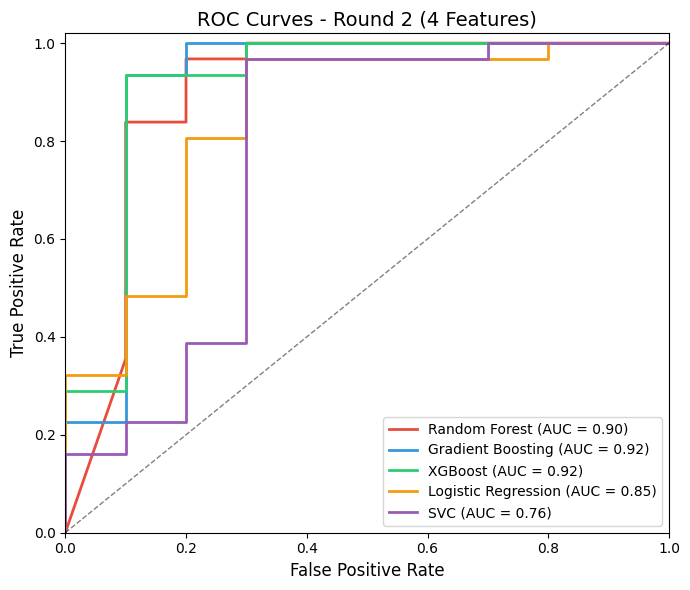

In [3]:
# ROC curves (reproduce Fig. 2c top panel)
from src.visualization import plot_roc_curves, save_fig
import matplotlib.pyplot as plt

fig = plot_roc_curves(results_r2, title="ROC Curves - Round 2 (4 Features)")
save_fig(fig, "roc_curves_round2.png")
plt.show()

In [4]:
# 10-fold Cross-validation for Random Forest (paper's evaluation protocol)
from src.models import cross_validate_model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_results = cross_validate_model(data['X_train_s'], y_train, rf, n_splits=10)
print(f"Random Forest 10-fold StratifiedShuffleSplit CV:")
print(f"  AUC:      {cv_results['auc_mean']:.4f} \u00b1 {cv_results['auc_std']:.4f}")
print(f"  Accuracy: {cv_results['acc_mean']:.4f} \u00b1 {cv_results['acc_std']:.4f}")
print(f"\nPaper reports: AUC = 0.87 \u00b1 0.06, Accuracy = 0.84")

Random Forest 10-fold StratifiedShuffleSplit CV:
  AUC:      0.7817 ± 0.0679
  Accuracy: 0.7971 ± 0.0533

Paper reports: AUC = 0.87 ± 0.06, Accuracy = 0.84


Saved: /home/yhm/desktop/code/anion-paper/figures/roc_mean_cv.png


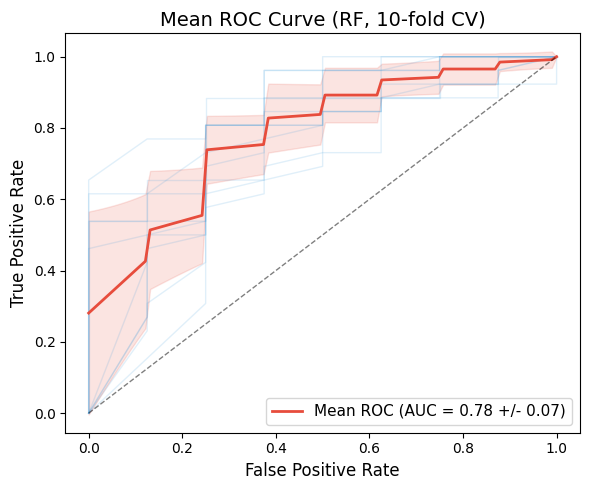

In [5]:
# Mean ROC curve with ±1 std band
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from src.visualization import plot_roc_with_cv, save_fig
import matplotlib.pyplot as plt

splitter = __import__('sklearn.model_selection', fromlist=['StratifiedShuffleSplit']).StratifiedShuffleSplit(
    n_splits=10, test_size=0.15, random_state=42
)
fprs, tprs = [], []
aucs = []
X_full = data['X_train_s']

for train_idx, test_idx in splitter.split(X_full, y_train):
    rf_cv = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_cv.fit(X_full.iloc[train_idx], y_train[train_idx])
    y_prob = rf_cv.predict_proba(X_full.iloc[test_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y_train[test_idx], y_prob)
    fprs.append(fpr)
    tprs.append(tpr)
    aucs.append(roc_auc_score(y_train[test_idx], y_prob))

fig = plot_roc_with_cv(fprs, tprs, np.mean(aucs), np.std(aucs),
                        title="Mean ROC Curve (RF, 10-fold CV)")
save_fig(fig, "roc_mean_cv.png")
plt.show()

Saved: /home/yhm/desktop/code/anion-paper/figures/lr_coefficients_round2.png


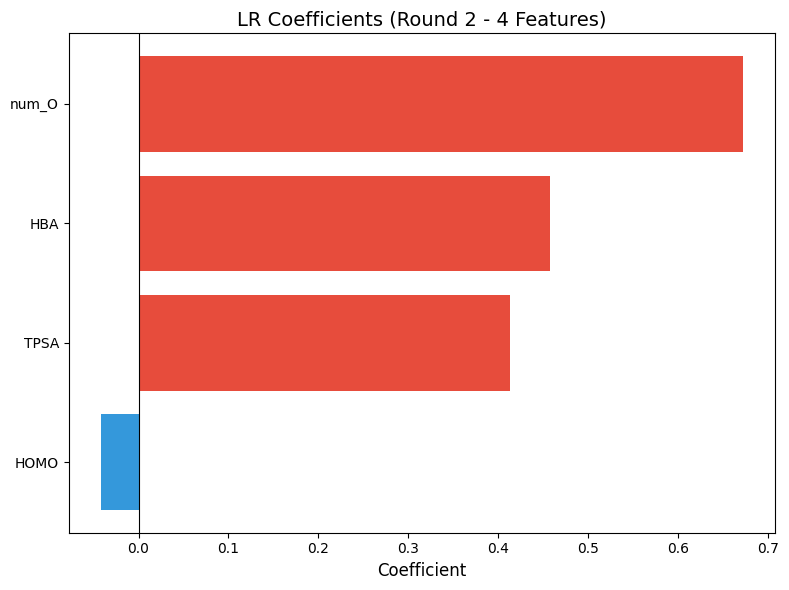

LR Coefficients:
        HOMO: -0.0421
        TPSA: +0.4124
         HBA: +0.4578
       num_O: +0.6717


In [6]:
# LR coefficients with 4 features
from src.models import get_feature_importance
from src.visualization import plot_lr_coefficients, save_fig

lr_model = results_r2['Logistic Regression']['model']
lr_coef = dict(zip(feature_names, lr_model.coef_[0]))
fig = plot_lr_coefficients(lr_coef, title="LR Coefficients (Round 2 - 4 Features)")
save_fig(fig, "lr_coefficients_round2.png")
plt.show()

print("LR Coefficients:")
for feat, coef in sorted(lr_coef.items(), key=lambda x: x[1]):
    print(f"  {feat:>10}: {coef:+.4f}")

In [7]:
# Save round 2 results
with open('../data/results_round2.pkl', 'wb') as f:
    pickle.dump({'results': results_r2, 'feature_names': feature_names, 'cv_results': cv_results}, f)
print("Round 2 results saved.")

Round 2 results saved.
